<img src="https://shwetkm.github.io/upxlogo.png"></img>

# Exploratory Data Analysis using Python(Part 02) - Data Science Foundation


**SET THE WORKING DIRECTORY SO THAT WE DO NOT HAVE TO THINK ABOUT PATH PROBLEMS**

Please ensure all your folder names <font color='red'><b>do not have a space & use forward slash (/)</b></font>

In [2]:
#your_local_path="F:/UpX-Series/DataScience/Mar2017/UpX-Co-March2017/DS_Foundation/Session-9/"
your_local_path="C:/Users/usha_/Downloads/UPx/Foundation/Week7/attachment_Datasets/Datasets/"

Techniques/questions to look at in this module:
<b><i>
+ How to merge datasets and different merge techniques
+ List of movies that are rated most by users
+ In ratings, how to address ratings sparsity problem
+ Plot distributions
+ Identify different age groups and technique of binning
+ Subgrouping and unstacking
+ Differences in ratings by gender
</b></i>

In [3]:
import pandas as pd
import numpy as np

In [4]:
# Pass column names in names for each CSV

# Load the users data
u_cols = ['user_id', 'age', 'sex', 'occupation', 'zip_code']
users = pd.read_csv(your_local_path+'u.user', sep='|', names=u_cols,
                    encoding='latin-1')

# Load the ratings data
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(your_local_path+'u.data', sep='\t', names=r_cols,
                      encoding='latin-1')

# the movies file contains columns indicating the movie's genres
# let's only load the first five columns of the file with usecols

# Load the movies data
m_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url']
movies = pd.read_csv(your_local_path+'u.item', sep='|', names=m_cols, usecols=range(5),
                     encoding='latin-1')
#can ignore the encoding = 'latin-1' part of it, the code will still work and is defaulted

In [5]:
# Check the structure of Users data
users.shape

(943, 5)

In [6]:
# Check few sample values of user data
users.head()

,user_id,age,sex,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [7]:
# Get information on user data
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
user_id       943 non-null int64
age           943 non-null int64
sex           943 non-null object
occupation    943 non-null object
zip_code      943 non-null object
dtypes: int64(2), object(3)
memory usage: 36.9+ KB


In [9]:
#check few sample values of user data 
#from IPython.core.Interactiveshell import InteractiveShell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [10]:
#check few sample values of user data 
#to print multiple outputs 
#from IPython.core.Interactiveshell import InteractiveShell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

users.head()
movies.head()
ratings.head()
users.shape
movies.shape
ratings.shape

,user_id,age,sex,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


,movie_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995)


,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


(943, 5)

(1682, 5)

(100000, 4)

In [25]:
print (users.head())
print (movies.head())
print (ratings.head())
print ('User Info:',users.shape)
print ('Movies Info:',movies.shape)
print ('Rating Info:',ratings.shape)

   user_id  age sex  occupation zip_code
0        1   24   M  technician    85711
1        2   53   F       other    94043
2        3   23   M      writer    32067
3        4   24   M  technician    43537
4        5   33   F       other    15213
   movie_id              title release_date  video_release_date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            imdb_url  
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...  
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...  
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...  
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...  
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)  
   user_id  movie_id 

In [26]:
# Get data type information of movies data
movies.dtypes

movie_id                int64
title                  object
release_date           object
video_release_date    float64
imdb_url               object
dtype: object

In [28]:
# Describe the spread of the users data
# gives the descriptive statistics for all the numerical variables
users.describe()

,user_id,age
count,943.000000,943.000000
mean,472.000000,34.051962
std,272.364951,12.192740
min,1.000000,7.000000
25%,236.500000,25.000000
50%,472.000000,31.000000
75%,707.500000,43.000000
max,943.000000,73.000000


In [29]:
# Get sample movie ids (top5 observations)
movies['movie_id'].head()

0    1
1    2
2    3
3    4
4    5
Name: movie_id, dtype: int64

In [32]:
# Selecting a subset of columns from the movies data (top 10 observations (default is 5))
movies[['movie_id','title']].head(10)

#KRP print the column names of the movie data ??

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6,7,Twelve Monkeys (1995)
7,8,Babe (1995)
8,9,Dead Man Walking (1995)
9,10,Richard III (1995)


In [33]:
# Another example of subsetting (Putting a condition)
#users[users.age<=50].tail(10)
users[users.age<=15]

,user_id,age,sex,occupation,zip_code
29,30,7,M,student,55436
100,101,15,M,student,05146
141,142,13,M,other,48118
178,179,15,M,entertainment,20755
205,206,14,F,student,53115
280,281,15,F,student,06059
288,289,11,M,none,94619
460,461,15,M,student,98102
470,471,10,M,student,77459
608,609,13,F,student,55106


In [35]:
# More conditions
#displays the Top3 (uses the default index ) users with age < 40, and sex = Female 
users[(users.age < 40) & (users.sex == 'F')].head(3)

,user_id,age,sex,occupation,zip_code
4,5,33,F,other,15213
10,11,39,F,other,30329
11,12,28,F,other,06405


In [40]:
users[users.age >= 70]

,age,sex,occupation,zip_code
user_id,,,,
481,73,M,retired,37771
767,70,M,engineer,00000
803,70,M,administrator,78212
860,70,F,retired,48322


In [46]:
# Create the index for the users dataset. Can run only once, do not run more than once, else you shall get an error.
users.set_index('user_id', inplace=True)
users.head()

,age,sex,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213


In [48]:
# If you wish then please reset the index
users.reset_index(inplace=True)
users.head()

,index,user_id,age,sex,occupation,zip_code
0,0,1,24,M,technician,85711
1,1,2,53,F,other,94043
2,2,3,23,M,writer,32067
3,3,4,24,M,technician,43537
4,4,5,33,F,other,15213


In [49]:
# Merge datasets - Movies, ratings & users
#movies.head()    # movie_id
#ratings.head()   # movie_id & user_id
#users.head()     # user_id

help (pd.merge)
movie_ratings = pd.merge(movies, ratings)
lens = pd.merge(movie_ratings, users)
#movie_ratings.head()

Help on function merge in module pandas.tools.merge:

merge(left, right, how='inner', on=None, left_on=None, right_on=None, left_index=False, right_index=False, sort=False, suffixes=('_x', '_y'), copy=True, indicator=False)
    Merge DataFrame objects by performing a database-style join operation by
    columns or indexes.
    
    If joining columns on columns, the DataFrame indexes *will be
    ignored*. Otherwise if joining indexes on indexes or indexes on a column or
    columns, the index will be passed on.
    
    Parameters
    ----------
    left : DataFrame
    right : DataFrame
    how : {'left', 'right', 'outer', 'inner'}, default 'inner'
        * left: use only keys from left frame (SQL: left outer join)
        * right: use only keys from right frame (SQL: right outer join)
        * outer: use union of keys from both frames (SQL: full outer join)
        * inner: use intersection of keys from both frames (SQL: inner join)
    on : label or list
        Field names to jo

In [29]:
lens.head()

,movie_id,title,release_date,video_release_date,imdb_url,user_id,rating,unix_timestamp,age,sex,occupation,zip_code
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,308,4,887736532,60,M,retired,95076
1,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,308,5,887737890,60,M,retired,95076
2,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),308,4,887739608,60,M,retired,95076
3,7,Twelve Monkeys (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Twelve%20Monk...,308,4,887738847,60,M,retired,95076
4,8,Babe (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Babe%20(1995),308,5,887736696,60,M,retired,95076


In [55]:
print ('Users: ', users.shape)
print ('Movies:',movies.shape)
print ('Ratings:', ratings.shape)
print ('After Join...')
# is the assumption below that 
print ('Movie_Ratings:',movie_ratings.shape)
print ('Lens:',lens.shape)

Users:  (943, 6)
Movies: (1682, 5)
Ratings: (100000, 4)
After Join...
Movie_Ratings: (100000, 8)
Lens: (100000, 13)


In [56]:
# Let us answer some simple questions now. 
# Most rated movies
#group by column name, size() = is the count of observations of the group in "group by", sort_values() = 

most_rated = lens.groupby('title').size().sort_values(ascending=False)
most_rated

title
Star Wars (1977)                                     583
Contact (1997)                                       509
Fargo (1996)                                         508
Return of the Jedi (1983)                            507
Liar Liar (1997)                                     485
English Patient, The (1996)                          481
Scream (1996)                                        478
Toy Story (1995)                                     452
Air Force One (1997)                                 431
Independence Day (ID4) (1996)                        429
Raiders of the Lost Ark (1981)                       420
Godfather, The (1972)                                413
Pulp Fiction (1994)                                  394
Twelve Monkeys (1995)                                392
Silence of the Lambs, The (1991)                     390
Jerry Maguire (1996)                                 384
Chasing Amy (1997)                                   379
Rock, The (1996)         

In [57]:
# Another way to get the mentions. 
#value_counts: The resulting object will be in descending order so that the first element is the most frequently-occurring 
lens.title.value_counts()[:20]

Star Wars (1977)                    583
Contact (1997)                      509
Fargo (1996)                        508
Return of the Jedi (1983)           507
Liar Liar (1997)                    485
English Patient, The (1996)         481
Scream (1996)                       478
Toy Story (1995)                    452
Air Force One (1997)                431
Independence Day (ID4) (1996)       429
Raiders of the Lost Ark (1981)      420
Godfather, The (1972)               413
Pulp Fiction (1994)                 394
Twelve Monkeys (1995)               392
Silence of the Lambs, The (1991)    390
Jerry Maguire (1996)                384
Chasing Amy (1997)                  379
Rock, The (1996)                    378
Empire Strikes Back, The (1980)     367
Star Trek: First Contact (1996)     365
Name: title, dtype: int64

In [59]:
# Highest rated movies
# agg - aggregate is a numpy function 
highest_ratings = lens.groupby('title').agg({'rating':[np.size,np.mean]})
highest_ratings.head()

# example for 'Till There was you - size = 9 (9 people have rated the move) and average rating is 2.33

rating          
                            size      mean
title                                     
'Til There Was You (1997)      9  2.333333
1-900 (1994)                   5  2.600000
101 Dalmatians (1996)        109  2.908257
12 Angry Men (1957)          125  4.344000
187 (1997)                    41  3.024390

In [60]:
# Let us sort the output and see what we get
#displays the top 5 movies with highest rating but lowest (ascending sort) no. of reviews 
highest_ratings.sort_values([('rating', 'mean')], ascending=False).head()

rating     
                                             size mean
title                                                 
They Made Me a Criminal (1939)                  1  5.0
Marlene Dietrich: Shadow and Light (1996)       1  5.0
Saint of Fort Washington, The (1993)            2  5.0
Someone Else's America (1995)                   1  5.0
Star Kid (1997)                                 3  5.0

In [63]:
# Now We shall consider movies that have been rated more than 100 times and print it in descending order on rating

atleast_100 = highest_ratings['rating']['size'] >= 100
highest_ratings[atleast_100].sort_values([('rating', 'mean')], ascending=False)[:15]

rating          
                                         size      mean
title                                                  
Close Shave, A (1995)                     112  4.491071
Schindler's List (1993)                   298  4.466443
Wrong Trousers, The (1993)                118  4.466102
Casablanca (1942)                         243  4.456790
Shawshank Redemption, The (1994)          283  4.445230
Rear Window (1954)                        209  4.387560
Usual Suspects, The (1995)                267  4.385768
Star Wars (1977)                          583  4.358491
12 Angry Men (1957)                       125  4.344000
Citizen Kane (1941)                       198  4.292929
To Kill a Mockingbird (1962)              219  4.292237
One Flew Over the Cuckoo's Nest (1975)    264  4.291667
Silence of the Lambs, The (1991)          390  4.289744
North by Northwest (1959)                 179  4.284916
Godfather, The (1972)                     413  4.283293

In [ ]:
#make the above descending order by no. of reviews 


In [64]:
import matplotlib.pyplot as plt
% matplotlib inline
# above line - that helps in displaying the output in the same window

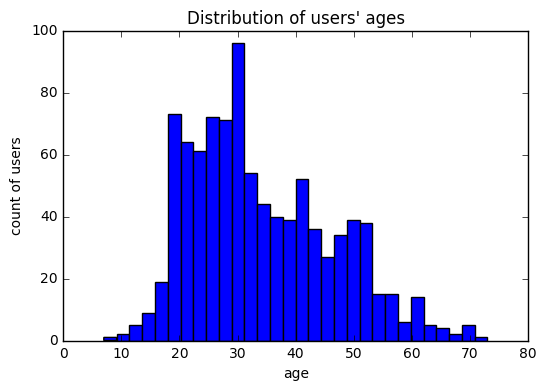

In [65]:
# Lets plot the user age and count
# bins = 30 as in 30 age-groups or the intervals

users.age.plot.hist(bins=30)
plt.title("Distribution of users' ages")
plt.ylabel('count of users')
plt.xlabel('age');


In [ ]:
# make the above diagram into normal distribution (hint: use CLT)

In [66]:
# How to get the 397 th user's age
lens['age'][397]

21

In [71]:
#help(pd.cut)
# Let us create buckets age-wise
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
lens['age_group'] = pd.cut(lens.age, range(0, 81, 10), right=False, labels=labels)
lens.head()

,movie_id,title,release_date,video_release_date,imdb_url,user_id,rating,unix_timestamp,index,age,sex,occupation,zip_code,age_group
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,308,4,887736532,307,60,M,retired,95076,60-69
1,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,308,5,887737890,307,60,M,retired,95076,60-69
2,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),308,4,887739608,307,60,M,retired,95076,60-69
3,7,Twelve Monkeys (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Twelve%20Monk...,308,4,887738847,307,60,M,retired,95076,60-69
4,8,Babe (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Babe%20(1995),308,5,887736696,307,60,M,retired,95076,60-69


In [73]:
# Group these age buckets and check the rating behaviour. Check who has given max & min number of ratings
# displays the age group that has given the maximum numbers of ratings and also the average rating 
lens.groupby('age_group').agg({'rating': [np.size, np.mean]})

rating          
            size      mean
age_group                 
0-9           43  3.767442
10-19       8181  3.486126
20-29      39535  3.467333
30-39      25696  3.554444
40-49      15021  3.591772
50-59       8704  3.635800
60-69       2623  3.648875
70-79        197  3.649746

In [75]:
# Get the top 100 most mentions
most_100 = lens.groupby('movie_id').size().sort_values(ascending=False)[:100]
most_100

movie_id
50     583
258    509
100    508
181    507
294    485
286    481
288    478
1      452
300    431
121    429
174    420
127    413
56     394
7      392
98     390
237    384
117    378
172    367
222    365
313    350
204    350
405    344
79     336
210    331
151    326
173    324
69     321
168    316
748    316
269    315
      ... 
132    246
125    244
228    244
144    243
483    243
194    241
245    240
323    240
197    239
185    239
11     236
282    232
496    231
568    230
301    230
265    227
655    227
182    226
273    223
143    222
179    221
180    221
471    221
161    220
71     220
8      219
95     219
427    219
678    219
322    218
dtype: int64

In [76]:
# Lets set the movie_id as the index
lens.set_index('movie_id', inplace=True)


In [77]:
# Lets split the observations by title and age group
by_age = lens.loc[most_100.index].groupby(['title', 'age_group'])
by_age.rating.mean().head(15)

title                         age_group
2001: A Space Odyssey (1968)  0-9          5.000000
                              10-19        4.100000
                              20-29        3.924731
                              30-39        3.887500
                              40-49        4.093023
                              50-59        4.000000
                              60-69        4.285714
Air Force One (1997)          10-19        3.647059
                              20-29        3.666667
                              30-39        3.570000
                              40-49        3.555556
                              50-59        3.750000
                              60-69        3.666667
                              70-79        3.666667
Aladdin (1992)                10-19        3.840000
Name: rating, dtype: float64

In [78]:
# Make it more presentable using unstack
by_age.rating.mean().unstack(1).fillna(0)[10:20]

age_group,0-9,10-19,20-29,30-39,40-49,50-59,60-69,70-79
title,,,,,,,,
"Birdcage, The (1996)",0.0,3.217391,3.413223,3.514286,3.500000,3.346154,3.888889,0.0
Blade Runner (1982),0.0,3.400000,4.134454,4.211765,4.147059,4.136364,4.400000,0.0
"Blues Brothers, The (1980)",0.0,4.214286,4.050505,3.637681,3.795455,3.450000,3.200000,0.0
Braveheart (1995),0.0,4.384615,4.194915,4.156627,4.051282,3.956522,3.714286,4.0
Broken Arrow (1996),0.0,3.363636,3.036697,2.938462,3.058824,3.052632,2.400000,0.0
Casablanca (1942),0.0,4.636364,4.447368,4.442857,4.530612,4.344828,4.285714,5.0
Chasing Amy (1997),0.0,4.130435,3.808333,3.679245,3.878788,3.789474,2.857143,0.0
"Clockwork Orange, A (1971)",0.0,4.600000,4.042105,3.688525,3.612903,4.176471,3.714286,0.0
Conspiracy Theory (1997),0.0,3.565217,3.382114,3.419355,3.465116,3.538462,2.600000,0.0


In [79]:
# Reset movie_id as index
lens.reset_index('movie_id', inplace=True)

In [80]:
# Let us pivot the data and split observations betweem male and female ratings

pivoted = lens.pivot_table(index=['movie_id', 'title'],
                           columns=['sex'],
                           values='rating',
                           fill_value=0)
pivoted.head()

,sex,F,M
movie_id,title,,
1,Toy Story (1995),3.789916,3.909910
2,GoldenEye (1995),3.368421,3.178571
3,Four Rooms (1995),2.687500,3.108108
4,Get Shorty (1995),3.400000,3.591463
5,Copycat (1995),3.772727,3.140625


In [81]:
# Try to find the rating behaviour difference between male and female
pivoted['diff'] = pivoted.M - pivoted.F
pivoted.head()

,sex,F,M,diff
movie_id,title,,,
1,Toy Story (1995),3.789916,3.909910,0.119994
2,GoldenEye (1995),3.368421,3.178571,-0.189850
3,Four Rooms (1995),2.687500,3.108108,0.420608
4,Get Shorty (1995),3.400000,3.591463,0.191463
5,Copycat (1995),3.772727,3.140625,-0.632102


In [82]:
# Reset movie_id as index again
pivoted.reset_index('movie_id', inplace=True)

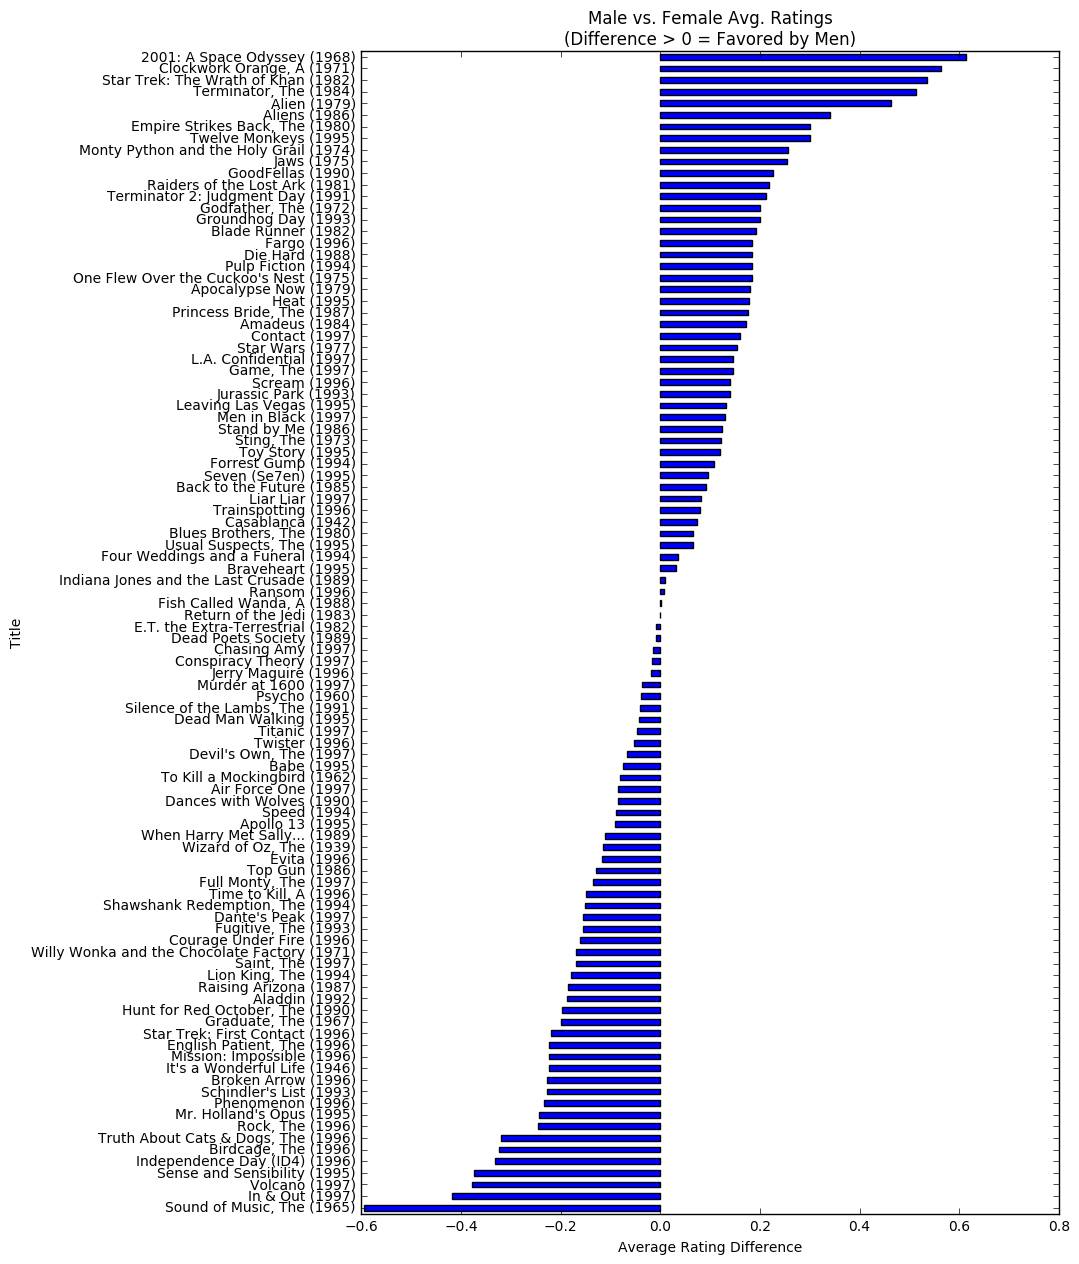

In [83]:
# Let us plot the rating differences between male and female and check for ourselves for patterns
disagreements = pivoted[pivoted.movie_id.isin(most_100.index)]['diff']
disagreements.sort_values().plot(kind='barh', figsize=[9, 15])
plt.title('Male vs. Female Avg. Ratings\n(Difference > 0 = Favored by Men)')
plt.ylabel('Title')
plt.xlabel('Average Rating Difference');